# Poor Code Do Not Use as Major Ref
# Emulating Distributed Quantum Computing (DQC) on a Single Chip

## Overview

This notebook demonstrates how to **emulate a distributed quantum computing scenario** using a single quantum processor. We partition a real IBM quantum chip into:

1. **Node A (Client)** - A local compute zone
2. **Node B (Server)** - A remote compute zone  
3. **Interconnect (Fiber)** - A quantum channel connecting them

The key insight is that we apply **different noise models** to different regions:
- **Compute nodes**: Low error (good superconducting qubits)
- **Interconnect**: High error (simulating photon loss in fiber optics)

This lets us study distributed quantum protocols without needing actual networked quantum computers.

---

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Understanding the Hardware Topology](#2-understanding-the-hardware-topology)
3. [Partitioning the Chip into Zones](#3-partitioning-the-chip-into-zones)
4. [Building the Hybrid Noise Model](#4-building-the-hybrid-noise-model)
5. [Implementing a Distributed CNOT Protocol](#5-implementing-a-distributed-cnot-protocol)
6. [Running the Emulation](#6-running-the-emulation)
7. [Analysis and Interpretation](#7-analysis-and-interpretation)

## 1. Import Libraries

We need several libraries:
- **rustworkx**: Graph algorithms for analyzing chip topology
- **qiskit**: Quantum circuit construction and transpilation
- **qiskit_ibm_runtime**: Access to fake (simulated) IBM backends with realistic noise
- **qiskit_aer**: High-performance quantum simulators with custom noise models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict

# Graph library for topology analysis
import rustworkx as rx
from rustworkx.visualization import mpl_draw

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram, plot_gate_map

# IBM Runtime fake providers (simulated backends with realistic properties)
from qiskit_ibm_runtime.fake_provider import FakeFez

# Aer simulator with noise modeling
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, 
    thermal_relaxation_error, 
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Understanding the Hardware Topology

### What is FakeFez?

`FakeFez` is a simulated version of a real IBM quantum processor. It provides:
- **Coupling map**: Which qubits can directly interact (2-qubit gates)
- **Noise properties**: T1/T2 times, gate errors, readout errors
- **Gate set**: Available native gates

IBM processors use a **Heavy Hex** lattice topology, which looks like a honeycomb pattern with additional connections. This topology is optimized for error correction.

### Why does topology matter for DQC?

In distributed quantum computing:
- **Nearby qubits** = Same compute node (fast, low error)
- **Distant qubits** = Different nodes connected by a channel (slow, high error)

We'll use the chip's topology to identify "distant" regions that we'll treat as separate compute nodes.

In [2]:
# Load the FakeFez backend
backend = FakeFez()

# Basic backend information
print("=" * 60)
print("BACKEND INFORMATION: FakeFez")
print("=" * 60)
print(f"Number of qubits: {backend.num_qubits}")
print(f"Basis gates: {backend.operation_names}")

# Get the coupling map (which qubits can interact)
coupling_map = backend.coupling_map
coupling_edges = coupling_map.get_edges()

print(f"\nCoupling map edges (first 20): {coupling_edges[:20]}...")
print(f"Total edges: {len(coupling_edges)}")

BACKEND INFORMATION: FakeFez
Number of qubits: 156
Basis gates: ['x', 'id', 'switch_case', 'rz', 'if_else', 'reset', 'sx', 'delay', 'measure', 'cz', 'for_loop']

Coupling map edges (first 20): [(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8)]...
Total edges: 352


In [3]:
# Build a graph representation using rustworkx for analysis
hw_graph = rx.PyDiGraph()
hw_graph.add_nodes_from(range(backend.num_qubits))
hw_graph.add_edges_from_no_data(coupling_edges)

print(f"Hardware graph: {hw_graph.num_nodes()} nodes, {hw_graph.num_edges()} edges")

# Find some properties of the graph
# Degree = number of connections per qubit
degrees = [hw_graph.in_degree(i) + hw_graph.out_degree(i) for i in range(hw_graph.num_nodes())]
print(f"\nQubit connectivity (degree):")
print(f"  Min degree: {min(degrees)} (edge qubits)")
print(f"  Max degree: {max(degrees)} (hub qubits)")
print(f"  Average degree: {np.mean(degrees):.1f}")

Hardware graph: 156 nodes, 352 edges

Qubit connectivity (degree):
  Min degree: 2 (edge qubits)
  Max degree: 6 (hub qubits)
  Average degree: 4.5


## 3. Partitioning the Chip into Zones

### The DQC Emulation Model

We'll divide the chip into three logical zones:

| Zone | Physical Meaning | Emulated As |
|------|------------------|-------------|
| **Node A** | Client compute node | Low-noise qubits (good superconducting qubits) |
| **Node B** | Server compute node | Low-noise qubits (good superconducting qubits) |
| **Channel** | Fiber optic interconnect | High-noise qubits (photon loss simulation) |

### Selecting the Zones

We need to:
1. Pick two **distant** regions on the chip for Node A and Node B
2. Find the **shortest path** between them (this becomes our "fiber channel")
3. The path qubits (excluding endpoints) form the interconnect

In [4]:
# ==========================================
# DEFINING THE ZONES
# ==========================================

# Node A (Client Rack) - Physical Qubits [0, 1]
# These are our "local" compute qubits
node_a_qubits = [0, 1]

# Node B (Server Rack) - Physical Qubits [14, 15]
# These are "remote" compute qubits, distant from Node A
node_b_qubits = [14, 15]

# Find the shortest path from Node A's edge (qubit 1) to Node B's edge (qubit 14)
# This represents finding the "fiber route" between data centers
path_dict = rx.dijkstra_shortest_paths(hw_graph, source=1, target=14)
path = path_dict[14]

# The "Channel" is the qubits in the path EXCLUDING the endpoints
# Endpoints belong to the compute nodes, middle qubits are the "fiber"
# path = [1, 2, 3, ..., 14] -> channel = [2, 3, ...]
channel_qubits = list(path[1:-1])

print("=" * 60)
print("DATA CENTER TOPOLOGY")
print("=" * 60)
print(f"\n🖥️  Node A (Client): qubits {node_a_qubits}")
print(f"    - Qubit {node_a_qubits[0]}: Computation qubit")
print(f"    - Qubit {node_a_qubits[1]}: Network port (gateway to channel)")

print(f"\n🖥️  Node B (Server): qubits {node_b_qubits}")
print(f"    - Qubit {node_b_qubits[0]}: Network port (gateway from channel)")
print(f"    - Qubit {node_b_qubits[1]}: Computation qubit")

print(f"\n🔗 Interconnect (Fiber): qubits {channel_qubits}")
print(f"    - Full path: {list(path)}")
print(f"    - Path length: {len(path)-1} hops (SWAP operations needed)")

# Verify there's no overlap
all_qubits = set(node_a_qubits) | set(node_b_qubits) | set(channel_qubits)
print(f"\n✓ Total qubits used: {len(all_qubits)}")
print(f"✓ No overlap between zones: {len(all_qubits) == len(node_a_qubits) + len(node_b_qubits) + len(channel_qubits)}")

DATA CENTER TOPOLOGY

🖥️  Node A (Client): qubits [0, 1]
    - Qubit 0: Computation qubit
    - Qubit 1: Network port (gateway to channel)

🖥️  Node B (Server): qubits [14, 15]
    - Qubit 14: Network port (gateway from channel)
    - Qubit 15: Computation qubit

🔗 Interconnect (Fiber): qubits [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    - Full path: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    - Path length: 13 hops (SWAP operations needed)

✓ Total qubits used: 16
✓ No overlap between zones: True


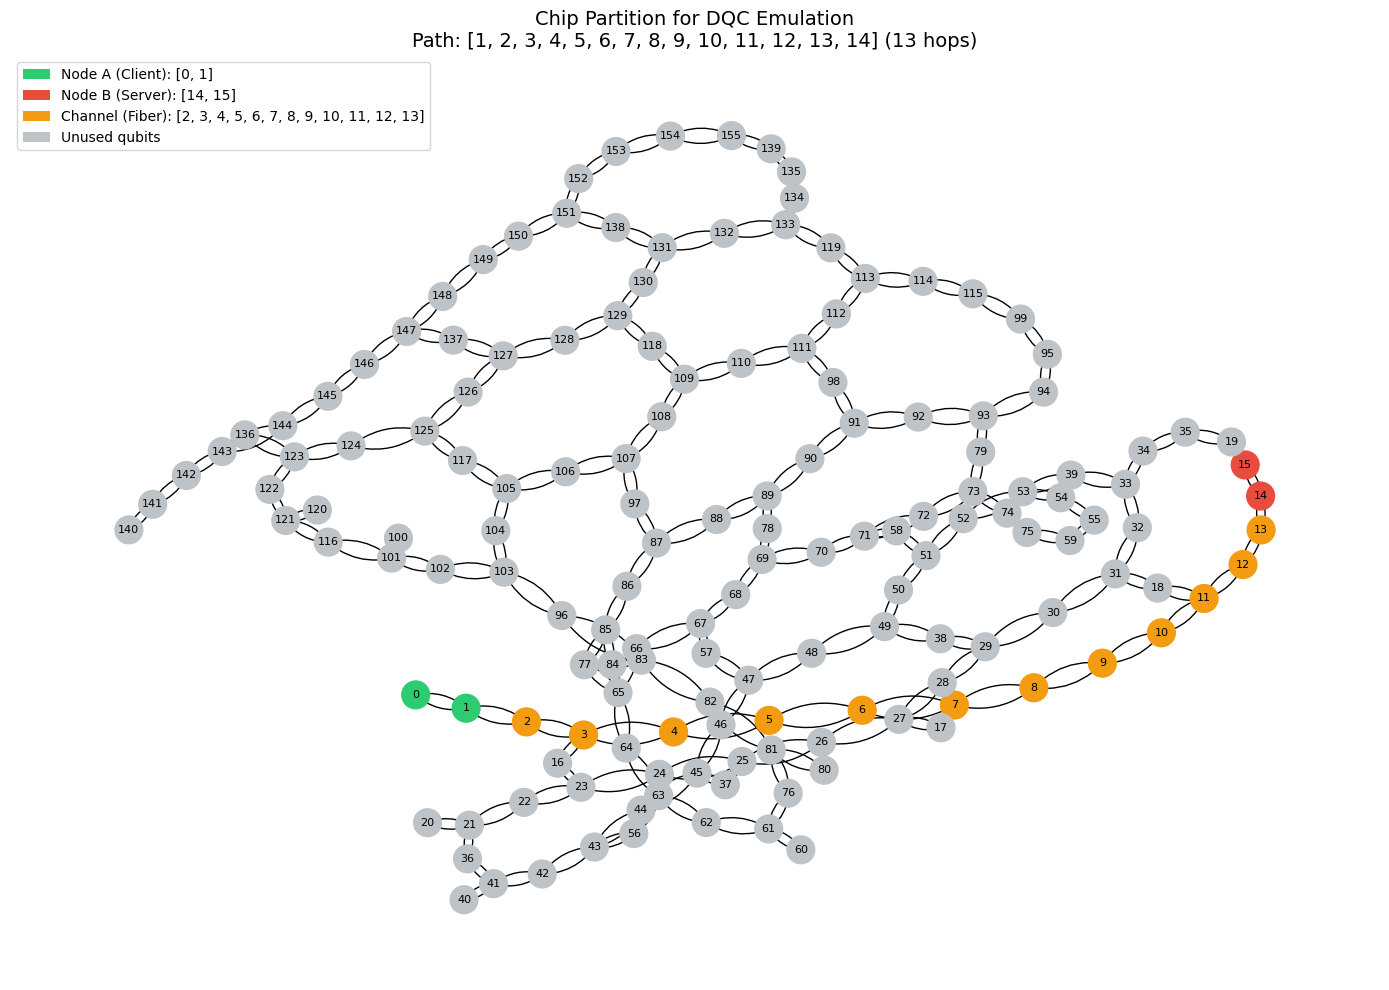

In [5]:
# Visualize the partition
def visualize_partition(hw_graph, node_a, node_b, channel, path):
    """Visualize the chip partition into zones."""
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Create node colors based on zone
    node_colors = []
    for i in range(hw_graph.num_nodes()):
        if i in node_a:
            node_colors.append('#2ecc71')  # Green - Node A
        elif i in node_b:
            node_colors.append('#e74c3c')  # Red - Node B
        elif i in channel:
            node_colors.append('#f39c12')  # Orange - Channel
        else:
            node_colors.append('#bdc3c7')  # Gray - Unused
    
    # Create node labels
    def label_fn(node_data):
        return str(node_data)
    
    # Draw the graph
    mpl_draw(hw_graph,
             ax=ax,
             with_labels=True,
             labels=label_fn,
             node_color=node_colors,
             node_size=400,
             font_size=8,
             arrows=False)
    
    ax.set_title(f"Chip Partition for DQC Emulation\n"
                 f"Path: {list(path)} ({len(path)-1} hops)", fontsize=14)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label=f'Node A (Client): {node_a}'),
        Patch(facecolor='#e74c3c', label=f'Node B (Server): {node_b}'),
        Patch(facecolor='#f39c12', label=f'Channel (Fiber): {channel}'),
        Patch(facecolor='#bdc3c7', label='Unused qubits'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    return fig

fig = visualize_partition(hw_graph, node_a_qubits, node_b_qubits, channel_qubits, path)
plt.show()

## 4. Building the Hybrid Noise Model

In real distributed quantum computing, different parts of the system experience different types of noise:

### Noise in Compute Nodes (Superconducting Qubits)
- **Gate errors**: Small depolarizing errors during operations
- **Decoherence**: T1 (energy relaxation) and T2 (dephasing) processes
- Modern superconducting qubits have T1, T2 ~ 100-300 μs

### Noise in Fiber Channels (Photonic Qubits)
- **Photon loss**: The dominant error in optical fibers (~0.2 dB/km)
- **Phase noise**: Small random phase shifts
- **Conversion losses**: Transducing between microwave and optical domains

### Our Hybrid Model
We create a **composite noise model** that applies:
1. **Thermal relaxation** (T1/T2) on channel qubits - simulating photon loss and decoherence in the fiber
2. **Depolarizing errors** on channel qubits - additional decoherence from transduction
3. **Depolarizing errors** on all CNOT gates - gate imperfections

This creates a realistic scenario where the "fiber" (channel qubits) is significantly noisier than the compute nodes.

In [6]:
# ==========================================
# HYBRID NOISE MODEL
# ==========================================

# Noise parameters - tunable to simulate different conditions
FIBER_T1 = 50e3        # T1 for fiber channel (ns) - shorter = more photon loss
FIBER_T2 = 30e3        # T2 for fiber channel (ns) - phase decoherence
GATE_TIME = 100        # Approximate gate time (ns)
FIBER_DEPOL = 0.02     # Additional depolarizing on fiber qubits
CX_ERROR = 0.01        # CNOT gate error rate

print("=== Hybrid Noise Model Parameters ===")
print(f"Fiber T1: {FIBER_T1/1e3:.1f} μs")
print(f"Fiber T2: {FIBER_T2/1e3:.1f} μs")  
print(f"Gate time: {GATE_TIME} ns")
print(f"Fiber depolarizing: {FIBER_DEPOL*100:.1f}%")
print(f"CX error rate: {CX_ERROR*100:.1f}%")

# Build the noise model
noise_model = NoiseModel()

# 1. Thermal relaxation on channel qubits (simulating fiber loss)
# This models the probability of a photon being absorbed or phase-shifted
thermal_error = thermal_relaxation_error(
    t1=FIBER_T1,
    t2=FIBER_T2,
    time=GATE_TIME
)
print(f"\nThermal relaxation error probabilities:")
print(f"  - This simulates decoherence in the optical fiber")

# 2. Compose with depolarizing error for channel qubits
# Depolarizing adds uniform randomization - models imperfect transduction
depol_fiber = depolarizing_error(FIBER_DEPOL, 1)
fiber_error = thermal_error.compose(depol_fiber)

# Apply fiber noise only to channel qubits (the "optical path")
for qubit in channel_qubits:
    noise_model.add_quantum_error(fiber_error, ['u1', 'u2', 'u3', 'sx', 'x', 'rz'], [qubit])
    
print(f"\nApplied fiber noise to {len(channel_qubits)} channel qubits: {channel_qubits}")

# 3. Gate errors on all CNOT operations
cx_error = depolarizing_error(CX_ERROR, 2)
noise_model.add_all_qubit_quantum_error(cx_error, ['cx'])

print(f"\nApplied CX error ({CX_ERROR*100}%) to all CNOT gates")
print(f"\nNoise model ready: {noise_model}")

=== Hybrid Noise Model Parameters ===
Fiber T1: 50.0 μs
Fiber T2: 30.0 μs
Gate time: 100 ns
Fiber depolarizing: 2.0%
CX error rate: 1.0%

Thermal relaxation error probabilities:
  - This simulates decoherence in the optical fiber

Applied fiber noise to 12 channel qubits: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Applied CX error (1.0%) to all CNOT gates

Noise model ready: NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3', 'x']
  Instructions with noise: ['u3', 'u1', 'x', 'rz', 'sx', 'u2', 'cx']
  Qubits with noise: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
  All-qubits errors: ['cx']
  Specific qubit errors: [('u1', (2,)), ('u1', (3,)), ('u1', (4,)), ('u1', (5,)), ('u1', (6,)), ('u1', (7,)), ('u1', (8,)), ('u1', (9,)), ('u1', (10,)), ('u1', (11,)), ('u1', (12,)), ('u1', (13,)), ('u2', (2,)), ('u2', (3,)), ('u2', (4,)), ('u2', (5,)), ('u2', (6,)), ('u2', (7,)), ('u2', (8,)), ('u2', (9,)), ('u2', (10,)), ('u2', (11,)), ('u2', (12,)), ('u2', (13,)), ('u3', (2,)), ('u3'

## 5. The Distributed CNOT Protocol

Now we build the actual quantum circuit that emulates a **distributed CNOT** operation.

### The Challenge
Alice (Node A) has a control qubit and wants to apply a CNOT to Bob's (Node B) target qubit, but they're separated by a fiber channel. In DQC, this would typically require:
1. Entanglement distribution
2. Local operations
3. Classical communication

### Our Emulation Approach
On our single chip, we **emulate** this by:
1. **Initialize**: Put Alice's qubit in superposition with Hadamard gate
2. **State Transfer**: SWAP the qubit state along the shortest path through the "fiber"
3. **Remote Operation**: Apply CNOT at Bob's location
4. **Measurement**: Measure in computational basis

This captures the essence of distributed quantum operations - the qubit must travel through a noisy channel to interact with a remote qubit.

### Circuit Diagram
```
Node A (Alice)           Fiber Channel              Node B (Bob)
  q_alice ──[H]──[SWAP]─────[SWAP]────...────[SWAP]──●───────[M]
                                                      │
  q_bob   ─────────────────────────────────────────────⊕───[M]
```

In [7]:
# ==========================================
# BUILD THE DISTRIBUTED CNOT CIRCUIT
# ==========================================

# Define our logical qubits
# Alice's computation qubit is at Node A
alice_qubit = node_a_qubits[0]  # Alice's control qubit (computation)
alice_port = node_a_qubits[1]   # Alice's network port (gateway)

# Bob's computation qubit is at Node B  
bob_port = node_b_qubits[0]     # Bob's network port (gateway) - this is path[-1]
bob_qubit = node_b_qubits[1]    # Bob's target qubit (computation)

print(f"=== Distributed CNOT Setup ===")
print(f"Alice (control) computation qubit: {alice_qubit}")
print(f"Alice network port: {alice_port}")
print(f"Bob network port: {bob_port}")
print(f"Bob (target) computation qubit: {bob_qubit}")
print(f"Channel path: {list(path)}")
print(f"Channel length: {len(path)-1} hops")

# Create quantum circuit
# We need registers for all qubits we'll use
all_qubits = set([alice_qubit, alice_port, bob_port, bob_qubit] + list(channel_qubits))
max_qubit = max(all_qubits)
num_qubits_needed = max_qubit + 1

qc = QuantumCircuit(num_qubits_needed, 2)  # 2 classical bits for measurement

# STEP 1: Initialize Alice's qubit in superposition
# |+⟩ = (|0⟩ + |1⟩)/√2
qc.h(alice_qubit)
qc.barrier(label="Init")

print(f"\nCircuit construction:")
print(f"  1. H gate on Alice (qubit {alice_qubit}) → creates superposition")

# STEP 2: Move state from computation qubit to network port
qc.swap(alice_qubit, alice_port)
print(f"  2. SWAP({alice_qubit}, {alice_port}) → move to network port")

# STEP 3: SWAP chain to transfer state through the fiber
# Each SWAP moves the quantum state one hop closer to Bob
print(f"  3. SWAP chain through fiber:")
for i in range(len(path) - 1):
    q1, q2 = path[i], path[i + 1]
    qc.swap(q1, q2)
    print(f"     SWAP({q1}, {q2})")

qc.barrier(label="Transfer")

# After SWAPs, Alice's state is now at bob_port (path[-1] = 14)
# STEP 4: Apply CNOT between Bob's network port (control) and computation qubit (target)
print(f"  4. CX gate: control at Bob's port ({bob_port}), target at Bob's compute ({bob_qubit})")
qc.cx(bob_port, bob_qubit)
qc.barrier(label="Remote CX")

# STEP 5: Measure both qubits
qc.measure(bob_port, 0)   # Measure the control (Alice's transported state)
qc.measure(bob_qubit, 1)  # Measure the target (Bob's computation qubit)

print(f"  5. Measure qubits {bob_port} and {bob_qubit}")
print(f"\nTotal circuit depth before transpilation: {qc.depth()}")

=== Distributed CNOT Setup ===
Alice (control) computation qubit: 0
Alice network port: 1
Bob network port: 14
Bob (target) computation qubit: 15
Channel path: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Channel length: 13 hops

Circuit construction:
  1. H gate on Alice (qubit 0) → creates superposition
  2. SWAP(0, 1) → move to network port
  3. SWAP chain through fiber:
     SWAP(1, 2)
     SWAP(2, 3)
     SWAP(3, 4)
     SWAP(4, 5)
     SWAP(5, 6)
     SWAP(6, 7)
     SWAP(7, 8)
     SWAP(8, 9)
     SWAP(9, 10)
     SWAP(10, 11)
     SWAP(11, 12)
     SWAP(12, 13)
     SWAP(13, 14)
  4. CX gate: control at Bob's port (14), target at Bob's compute (15)
  5. Measure qubits 14 and 15

Total circuit depth before transpilation: 17


In [8]:
# Visualize the circuit
print("=== Distributed CNOT Circuit ===")
print(qc.draw(output='text', fold=120))

=== Distributed CNOT Circuit ===
      ┌───┐ Init                                            Transfer       Remote CX       
 q_0: ┤ H ├──░────X────────────────────────────────────────────░───────────────░───────────
      └───┘  ░    │                                            ░               ░           
 q_1: ───────░────X──X─────────────────────────────────────────░───────────────░───────────
             ░       │                                         ░               ░           
 q_2: ───────░───────X──X──────────────────────────────────────░───────────────░───────────
             ░          │                                      ░               ░           
 q_3: ───────░──────────X──X───────────────────────────────────░───────────────░───────────
             ░             │                                   ░               ░           
 q_4: ───────░─────────────X──X────────────────────────────────░───────────────░───────────
             ░                │                

## 6. Running the DQC Emulation

Now we run the emulation:
1. **Transpile** the circuit for the actual hardware topology
2. **Simulate** with our hybrid noise model
3. **Collect statistics** from many shots

### Expected Behavior
- **Ideal case (no noise)**: We expect to see correlated outcomes from the CNOT:
  - `|00⟩` and `|11⟩` with equal probability (Bell-like correlations)
  
- **With noise**: The signal degrades as:
  - More errors in the fiber channel add random bit flips
  - Longer paths = more SWAP operations = more accumulated error
  - We may see `|01⟩` and `|10⟩` outcomes (error states)

In [9]:
# ==========================================
# TRANSPILE AND RUN
# ==========================================

# Transpile to hardware topology
# This ensures our circuit respects the coupling map
transpiled_qc = transpile(
    qc,
    backend=backend,
    optimization_level=1
)

print(f"=== Transpilation Results ===")
print(f"Original depth: {qc.depth()}")
print(f"Transpiled depth: {transpiled_qc.depth()}")
print(f"Transpiled gate count: {transpiled_qc.count_ops()}")

# Create simulator with noise model
simulator = AerSimulator(noise_model=noise_model)

# Run the simulation
NUM_SHOTS = 8192
print(f"\n=== Running Simulation ===")
print(f"Shots: {NUM_SHOTS}")
print(f"Noise model: Hybrid (thermal + depolarizing)")

job = simulator.run(transpiled_qc, shots=NUM_SHOTS)
result = job.result()
counts = result.get_counts()

print(f"\n=== Results ===")
print(f"Raw counts: {counts}")

=== Transpilation Results ===
Original depth: 17
Transpiled depth: 95
Transpiled gate count: OrderedDict({'sx': 87, 'cz': 43, 'rz': 6, 'barrier': 3, 'measure': 2})

=== Running Simulation ===
Shots: 8192
Noise model: Hybrid (thermal + depolarizing)

=== Results ===
Raw counts: {'11': 4008, '00': 4184}


## 7. Analyzing the Results

Let's visualize and interpret our results:
1. **Histogram** of measurement outcomes
2. **Fidelity analysis** - how well did the distributed CNOT work?
3. **Error breakdown** - what types of errors occurred?

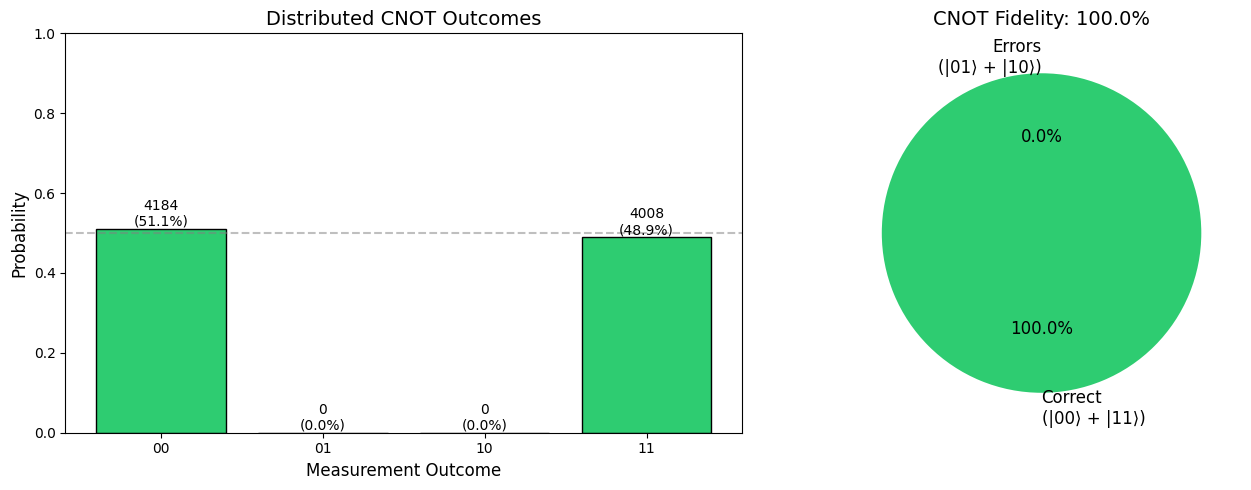

=== Detailed Analysis ===
Expected outcomes (|00⟩, |11⟩): 8192 shots (100.0%)
Error outcomes (|01⟩, |10⟩): 0 shots (0.0%)

Interpretation:
  - Fidelity > 90%: Excellent - fiber channel works well
  - Fidelity 70-90%: Good - some noise but signal preserved
  - Fidelity 50-70%: Poor - significant decoherence
  - Fidelity ~ 50%: Failed - complete decoherence (random outcomes)


In [10]:
# ==========================================
# VISUALIZATION AND ANALYSIS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of results
ax1 = axes[0]
outcomes = ['00', '01', '10', '11']
counts_normalized = {outcome: counts.get(outcome, 0) / NUM_SHOTS for outcome in outcomes}

colors = ['#2ecc71', '#e74c3c', '#e74c3c', '#2ecc71']  # Green=expected, Red=error
bars = ax1.bar(outcomes, [counts_normalized[o] for o in outcomes], color=colors, edgecolor='black')

ax1.set_xlabel('Measurement Outcome', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Distributed CNOT Outcomes', fontsize=14)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Ideal')

# Add count labels
for bar, outcome in zip(bars, outcomes):
    height = bar.get_height()
    ax1.annotate(f'{counts.get(outcome, 0)}\n({height:.1%})',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=10)

# Plot 2: Fidelity pie chart
ax2 = axes[1]
correct = counts.get('00', 0) + counts.get('11', 0)  # Expected outcomes
errors = counts.get('01', 0) + counts.get('10', 0)   # Error outcomes

fidelity = correct / NUM_SHOTS
error_rate = errors / NUM_SHOTS

ax2.pie([fidelity, error_rate], 
        labels=['Correct\n(|00⟩ + |11⟩)', 'Errors\n(|01⟩ + |10⟩)'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title(f'CNOT Fidelity: {fidelity:.1%}', fontsize=14)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("=== Detailed Analysis ===")
print(f"Expected outcomes (|00⟩, |11⟩): {correct} shots ({fidelity:.1%})")
print(f"Error outcomes (|01⟩, |10⟩): {errors} shots ({error_rate:.1%})")
print(f"\nInterpretation:")
print(f"  - Fidelity > 90%: Excellent - fiber channel works well")
print(f"  - Fidelity 70-90%: Good - some noise but signal preserved")
print(f"  - Fidelity 50-70%: Poor - significant decoherence")
print(f"  - Fidelity ~ 50%: Failed - complete decoherence (random outcomes)")

## 8. Experimenting with Parameters

Let's explore how different parameters affect the DQC performance. This helps us understand:
- How fiber loss affects entanglement fidelity
- The impact of path length on quantum operations
- Trade-offs in distributed quantum computing

=== Fiber Quality Sweep (T1) ===
  T1 =   10.0 μs → Fidelity: 100.0%
  T1 =   20.0 μs → Fidelity: 100.0%
  T1 =   50.0 μs → Fidelity: 100.0%
  T1 =  100.0 μs → Fidelity: 100.0%
  T1 =  200.0 μs → Fidelity: 100.0%
  T1 =  500.0 μs → Fidelity: 100.0%


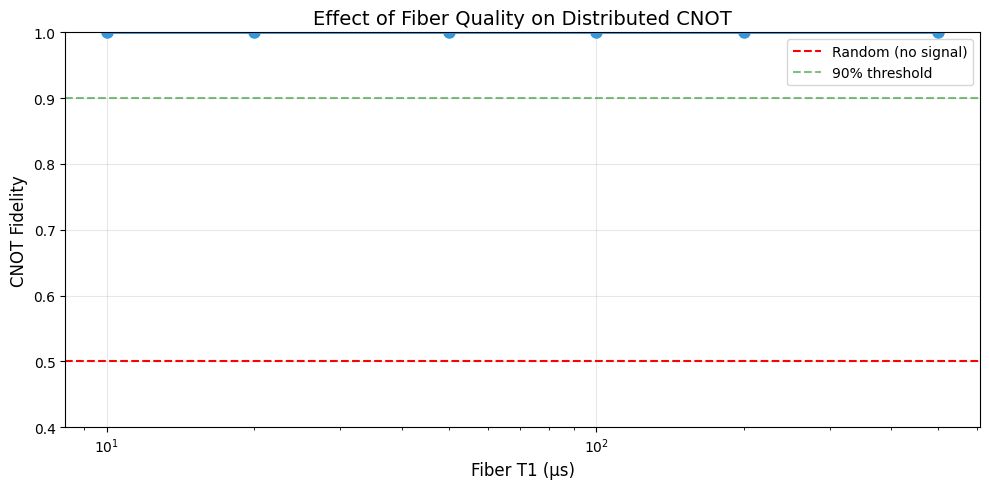


Interpretation:
  - Shorter T1 = more photon loss = lower fidelity
  - Longer T1 = better fiber = quantum info preserved
  - Real optical fibers: losses of 0.2 dB/km typical


In [11]:
# ==========================================
# PARAMETER SWEEP: Effect of Fiber Quality
# ==========================================

def run_dqc_experiment(fiber_t1, fiber_t2, fiber_depol, shots=4096):
    """Run DQC experiment with specified noise parameters."""
    
    # Build noise model
    nm = NoiseModel()
    thermal_err = thermal_relaxation_error(t1=fiber_t1, t2=fiber_t2, time=GATE_TIME)
    depol_err = depolarizing_error(fiber_depol, 1)
    fiber_err = thermal_err.compose(depol_err)
    
    for qubit in channel_qubits:
        nm.add_quantum_error(fiber_err, ['u1', 'u2', 'u3', 'sx', 'x', 'rz'], [qubit])
    nm.add_all_qubit_quantum_error(depolarizing_error(CX_ERROR, 2), ['cx'])
    
    # Run simulation
    sim = AerSimulator(noise_model=nm)
    result = sim.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    
    # Calculate fidelity
    correct = counts.get('00', 0) + counts.get('11', 0)
    return correct / shots

# Sweep fiber T1 (simulates different fiber lengths/losses)
t1_values = [10e3, 20e3, 50e3, 100e3, 200e3, 500e3]  # ns
fidelities_t1 = []

print("=== Fiber Quality Sweep (T1) ===")
for t1 in t1_values:
    fid = run_dqc_experiment(t1, t1 * 0.6, FIBER_DEPOL)
    fidelities_t1.append(fid)
    print(f"  T1 = {t1/1e3:6.1f} μs → Fidelity: {fid:.1%}")

# Plot results
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([t/1e3 for t in t1_values], fidelities_t1, 'o-', linewidth=2, markersize=8, color='#3498db')
ax.axhline(y=0.5, color='red', linestyle='--', label='Random (no signal)')
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='90% threshold')

ax.set_xlabel('Fiber T1 (μs)', fontsize=12)
ax.set_ylabel('CNOT Fidelity', fontsize=12)
ax.set_title('Effect of Fiber Quality on Distributed CNOT', fontsize=14)
ax.set_xscale('log')
ax.set_ylim(0.4, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Shorter T1 = more photon loss = lower fidelity")
print("  - Longer T1 = better fiber = quantum info preserved")
print("  - Real optical fibers: losses of 0.2 dB/km typical")

## 9. Conclusion

### What We Learned

This notebook demonstrated how to **emulate distributed quantum computing on a single superconducting chip**:

1. **Topology Matters**: We used the real coupling map of IBM's Heron processor to partition qubits into logical zones (compute nodes + fiber channel).

2. **Noise Modeling**: Different parts of a DQC system experience different noise:
   - Compute nodes: Gate errors, short decoherence times
   - Fiber channels: Photon loss (thermal relaxation), phase noise

3. **Distributed Operations**: A "remote" CNOT requires moving quantum information through the network via SWAP chains, accumulating errors along the way.

4. **Fidelity vs Distance**: Longer paths = more SWAPs = lower fidelity. This is the fundamental trade-off in quantum networks.

### Real-World Implications

In actual DQC systems:
- **Entanglement-based protocols** (teleportation, entanglement swapping) replace our SWAP chains
- **Quantum repeaters** extend range by correcting errors
- **Error correction** can boost fidelity at the cost of more qubits
- **Heterogeneous hardware** (superconducting + photonic + trapped ions) presents integration challenges

### Next Steps
- Try different node placements on the chip
- Implement entanglement-based CNOT protocols
- Add error mitigation techniques
- Scale to multi-node networks